# 1.set up environment

In [4]:
%matplotlib ipympl
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置 Scanpy 参数
sc.settings.verbosity = 3
sc.set_figure_params(dpi=100, facecolor='white')
print("Environment Ready!")

Environment Ready!


# 2.load raw count data (pandas)

In [29]:
data_path = "../data/raw_matrix/GSE99254_NSCLC.TCell.S12346.count.txt"
print("Loading raw matrix...")
df_raw = pd.read_csv(data_path, sep='\t')
#df_raw.head()
# 提取 gene_id 和 symbol，并以 gene_id 为索引
gene_metadata = df_raw[['geneID', 'symbol']].set_index('geneID')
gene_metadata.index = gene_metadata.index.astype(str)

# 去除 symbol 列，设置 geneID 为索引，然后转置为 (Cells x Genes)
count_matrix = df_raw.drop(columns=['symbol']).set_index('geneID')
count_matrix.index = count_matrix.index.astype(str)
count_matrix = count_matrix.T

#构建标准 AnnData 对象
adata = sc.AnnData(X=count_matrix)
adata.obs_names = adata.obs_names.astype(str)
adata.var = gene_metadata  # 将基因信息放入 var
adata.var_names_make_unique() # 确保基因名唯一

print(f"AnnData Build Success!")
print(f"AnnData initialized: {adata.n_obs} cells x {adata.n_vars} genes")

Loading raw matrix...
AnnData Build Success!
AnnData initialized: 12346 cells x 23459 genes


# 3.QC
3.1 数据质控 (QC) 的重要性
单细胞分析的第一步是排除低质量数据。我们主要关注三个指标：
* **n_genes_by_counts**: 检测到的基因总数（判断细胞活性）。如果太低，可能是死细胞或空孔。
* **total_counts**: 细胞的总测序深度（UMI 或 Reads 总数）。
* **pct_counts_mt**: 线粒体基因占比。如果过高（如 > 10%），通常代表细胞膜破裂，胞质 RNA 流失，只剩下线粒体。

3.2 Scanpy 质控函数参数解析
在运行 `sc.pp.calculate_qc_metrics` 时，关键参数如下：
* **`percent_top=None`**: 
    - *含义*：不计算前 N 个高表达基因的占比。
    - *理由*：Smart-seq2 数据基因检出率高，库多样性较好，通常无需关注特定极少数基因的过表达占比。
* **`log1p=False`**: 
    - *含义*：不对计算出的指标进行 $\log(x + 1)$ 转换。
    - *理由*：在质控阶段，保持原始计数值（Raw Counts）更符合生物直觉，便于设定过滤阈值（Thresholds）。
* **`inplace=True`**: 
    - *含义*：直接修改 `adata` 对象。
    - *理由*：将 QC 结果直接存入 `adata.obs` 槽位，确保细胞属性与表达矩阵实时对齐。

3.3 可视化技巧：Jitter（抖动）
在调用 `sc.pl.violin` 时设置了 `jitter=0.4`：
* **原理**：在小提琴图的分类轴方向上为每个数据点增加随机的水平位移。
* **作用**：防止数万个细胞的数据点在同一数值上完全重叠成一条线。
* **效果**：通过点的疏密程度观察数据的**分布密度**，点越密集的地方代表该数值范围内的细胞数量越多。

T 细胞核心标志基因 (CD3) 存在情况：


,symbol,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
geneID,,,,,
915,CD3D,12284,451.505265,0.502187,5574284
916,CD3E,11822,345.454317,4.244290,4264979
917,CD3G,10942,241.548356,11.372104,2982156


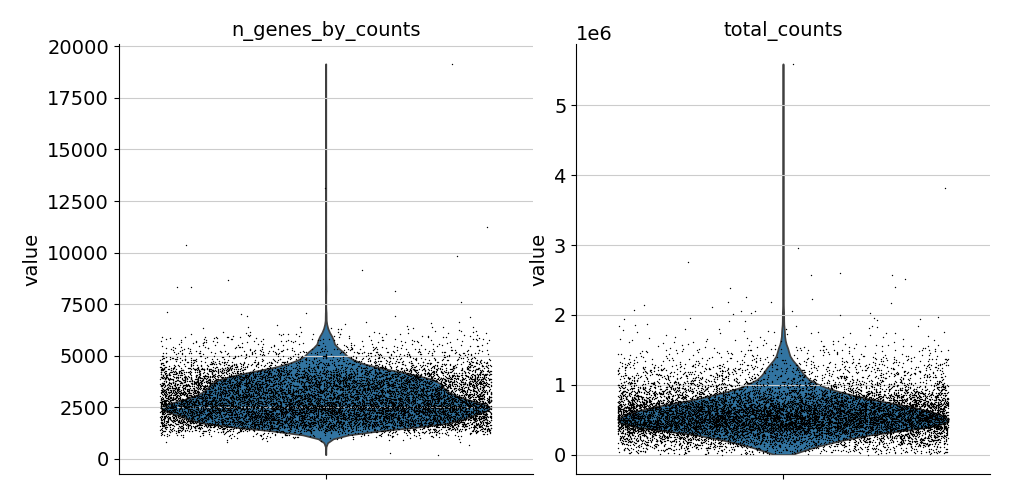

,n_genes_by_counts,total_counts,pct_counts_mt
count,12346.000000,1.234600e+04,12346.0
mean,2938.957557,5.966755e+05,0.0
std,1028.774831,3.011303e+05,0.0
min,203.000000,2.330000e+02,0.0
25%,2163.000000,4.004268e+05,0.0
50%,2799.000000,5.560695e+05,0.0
75%,3637.000000,7.429132e+05,0.0
max,19151.000000,5.595478e+06,0.0


In [30]:
# data have already been filtered, and this step is just for validation
# 1. 计算基础质控指标
# 虽然没有线粒体基因，但我们需要计算 n_genes_by_counts (基因数) 和 total_counts (测序深度)
# percent_top=None 是因为我们不需要看前 N 个高表达基因的占比
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)

# 2. Placeholder
# 为了兼容后续可能调用 'pct_counts_mt' 的可视化函数或管线，我们手动创建一个全为 0 的列
adata.obs['pct_counts_mt'] = 0.0

# 3. 核心标志基因 (Marker Genes) 验证
# 验证 CD3 家族基因是否存在，这是确保数据属于 T 细胞的最直接证据
cd3_markers = ['CD3D', 'CD3E', 'CD3G']
cd3_check = adata.var[adata.var['symbol'].isin(cd3_markers)]

print("T 细胞核心标志基因 (CD3) 存在情况：")
if not cd3_check.empty:
    display(cd3_check)
else:
    print( "警告：未发现 CD3 基因，请检查 Symbol 列是否正确。")

# 4. 可视化指标分布
# 观察基因数分布，确认是否还有极低质量的细胞（虽然作者已经过滤过了）
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts'], 
             jitter=0.4, multi_panel=True)

# 5. final statics
display(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe())

# 4.Normalization and Logarithmization
1. 库大小归一化：文献中提到了 TPM (Transcripts Per Million)。通过将每个细胞的总计数缩放到 $10^6$ (target_sum=1e6)，我们可以模拟 TPM 的量纲，使得测序深度不同的细胞具有可比性。
2. 对数变换：使用 $\log(X+1)$ 变换，目的是压缩高表达基因的极值，使数据分布更接近正态分布，从而满足后续聚类和差异表达分析的统计假设。

In [31]:
# --- Cell 4: 归一化与对数化 (TPM-like Transformation) ---

# 1. 备份原始计数数据到 .raw 属性中，方便后续在绘图时调用最原始的表达量
adata.raw = adata

# 2. 执行归一化
# 根据文献 TPM 逻辑，我们将每个细胞的总计数缩放到 1,000,000
sc.pp.normalize_total(adata, target_sum=1e6)
print(f"验证：前 5 个细胞的归一化总计数之和 (应均为 1e6):\n{adata.X.sum(axis=1)[:5]}")

# 3. 执行对数化
sc.pp.log1p(adata)


normalizing counts per cell
    finished (0:00:01)
验证：前 5 个细胞的归一化总计数之和 (应均为 1e6):
[1000000.06 1000000.    999999.94 1000000.   1000000.  ]


# 5.Highly Variable Genes, HVGs
文献提到作者选择了特定数量的高变基因进行后续分析。在 2018 年的方法中，通常关注在细胞间表达波动剧烈的基因（在某些细胞表达极高、在另一些细胞表达极低的基因），因为这些基因包含了区分 T 细胞亚群（如 CD8+ 耗竭 vs CD4+ 调节）的主要生物学信号。

extracting highly variable genes
    finished (0:00:06)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


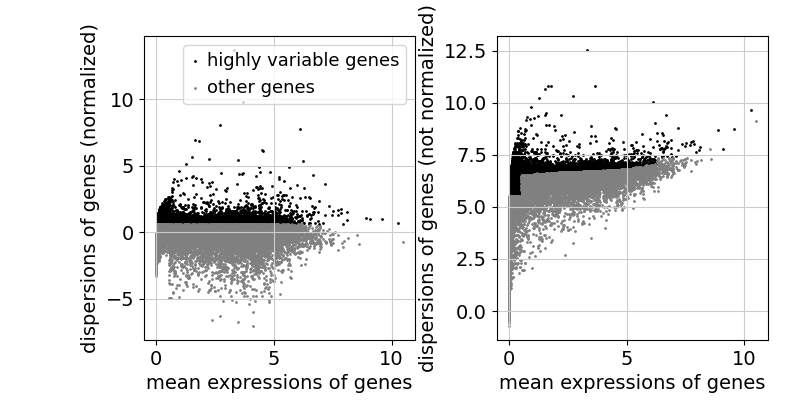

keep 6000 genes


In [46]:
#sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.highly_variable_genes(adata, n_top_genes=6000)

n_hvg = adata.var.highly_variable.sum()

# 可视化高变基因选择情况
sc.pl.highly_variable_genes(adata)

# 过滤数据，仅保留高变基因用于后续的降维和聚类，这一步是为了提高计算效率并减少噪声
adata_hvg = adata[:, adata.var.highly_variable].copy()

print(f"keep {n_hvg} genes")

# 6.Scaling & PCA
为了确保每个基因对后续主成分分析（PCA）的贡献是均等的（防止高表达基因主导结果），我们需要对数据进行 Scaling（中心化）。随后运行 PCA，将上千个基因的维度压缩到几十个主成分中。

computing PCA
    with n_comps=50
    finished (0:00:11)


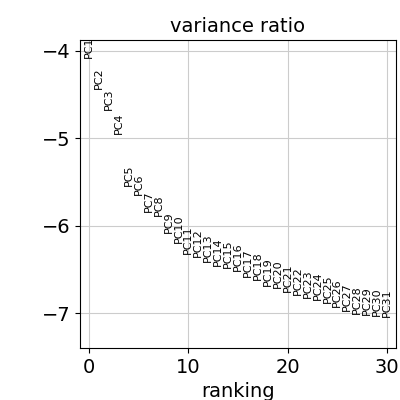

PCA 降维完成。请根据碎石图评估方差解释量。


In [48]:
# 1. 对高变基因数据进行中心化和标准化 (Scale)
# 设置 max_value=10 是为了防止个别极端表达值影响全局
sc.pp.scale(adata_hvg, max_value=10)

# 2. 运行 PCA，计算前 50 个主成分
sc.tl.pca(adata_hvg, svd_solver='arpack')

# 3. 绘制 Elbow Plot (碎石图)，帮助我们决定后续聚类使用多少个 PC (主成分)
sc.pl.pca_variance_ratio(adata_hvg, log=True)

print("PCA 降维完成。请根据碎石图评估方差解释量。")

观察点下降的斜率：
PC1 到 PC4：下降非常陡峭。这通常代表了数据中最核心的生物学差异（比如 CD8 vs CD4，或者 肿瘤组织 vs 外周血）。
PC5 到 PC10：坡度开始减缓，但依然有明显的阶梯。
PC11 之后：你可以看到曲线开始变得非常平滑，下降幅度很小。
结论：“手肘”大约出现在 PC10 到 PC15 之间

# save result

In [49]:
adata_hvg.write("hcc_t_cell_preprocessed.h5ad")